In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/cleaned_retail_inventory.csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Price,Units Sold,Inventory Level,Discount,Competitor Pricing,Year,Month,Day,Total Sales
0,2022-01-01,S001,P0001,Groceries,North,33.50,127,231,20,29.69,2022,1,1,4254.50
1,2022-01-01,S001,P0002,Toys,South,63.01,150,204,20,66.16,2022,1,1,9451.50
2,2022-01-01,S001,P0003,Toys,West,27.99,65,102,10,31.32,2022,1,1,1819.35
3,2022-01-01,S001,P0004,Toys,North,32.72,61,469,10,34.74,2022,1,1,1995.92
4,2022-01-01,S001,P0005,Electronics,East,73.64,14,166,0,68.95,2022,1,1,1030.96


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.weekday

In [ ]:
df["Original_Revenue"] = df["Price"] * df["Units Sold"]

In [ ]:
def demand_rule(row):

    if row["Units Sold"] > 50:
        return row["Price"] * 1.25   # 25% increase

    elif row["Units Sold"] < 10:
        return row["Price"] * 0.90   # 10% decrease

    else:
        return row["Price"]

In [ ]:
def inventory_rule(price, inventory):

    if inventory < 30:
        return price * 1.30   # strong increase

    elif inventory > 120:
        return price * 0.85

    else:
        return price

In [ ]:
def time_rule(price, weekday):

    if weekday >= 5:
        return price * 1.12
    else:
        return price

In [ ]:
def combo_rule(price, demand, inventory):

    if demand > 50 and inventory < 40:
        return price * 1.35
    else:
        return price

In [ ]:
def apply_dynamic_price(row):

    price = demand_rule(row)

    price = inventory_rule(price, row["Inventory Level"])

    price = time_rule(price, row["Weekday"])

    price = combo_rule(price, row["Units Sold"], row["Inventory Level"])

    return price

In [ ]:
df["Dynamic_Price"] = df.apply(apply_dynamic_price, axis=1)

In [ ]:
df["Dynamic_Revenue"] = df["Dynamic_Price"] * df["Units Sold"]

In [ ]:
original_revenue = df["Original_Revenue"].sum()
dynamic_revenue = df["Dynamic_Revenue"].sum()

print("Original Revenue:", original_revenue)
print("Dynamic Revenue:", dynamic_revenue)

Original Revenue: 550228884.91
Dynamic Revenue: 603780767.7454971


In [ ]:
revenue_lift = ((dynamic_revenue - original_revenue) / original_revenue) * 100

print("Revenue Lift (%):", revenue_lift)

Revenue Lift (%): 9.732655682781273


In [ ]:
df[["Price","Dynamic_Price","Original_Revenue","Dynamic_Revenue"]].head()

,Price,Dynamic_Price,Original_Revenue,Dynamic_Revenue
0,33.50,39.86500,4254.50,5062.85500
1,63.01,74.98190,9451.50,11247.28500
2,27.99,39.18600,1819.35,2547.09000
3,32.72,38.93680,1995.92,2375.14480
4,73.64,70.10528,1030.96,981.47392


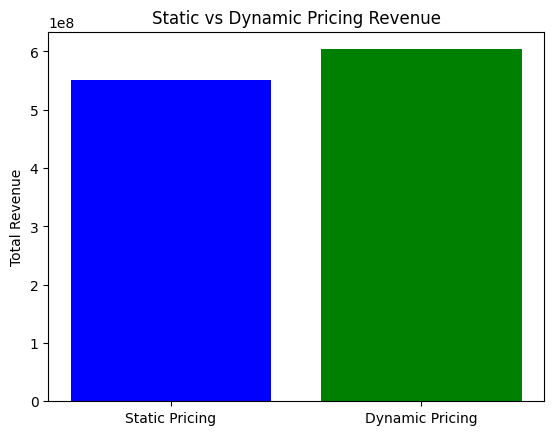

In [ ]:
import matplotlib.pyplot as plt

labels = ["Static Pricing", "Dynamic Pricing"]
revenues = [original_revenue, dynamic_revenue]

plt.bar(labels, revenues, color=["blue","green"])
plt.title("Static vs Dynamic Pricing Revenue")
plt.ylabel("Total Revenue")
plt.show()

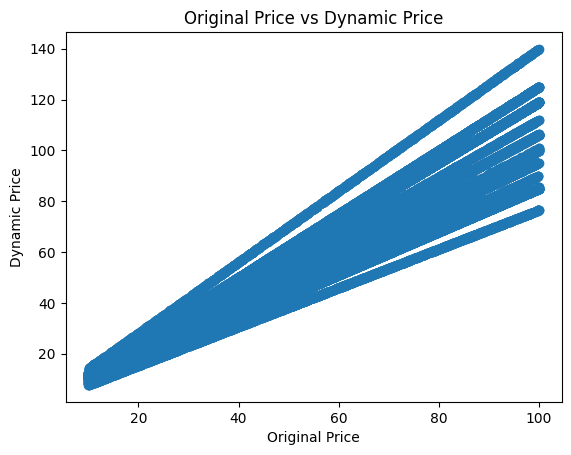

In [ ]:
plt.scatter(df["Price"], df["Dynamic_Price"])
plt.title("Original Price vs Dynamic Price")
plt.xlabel("Original Price")
plt.ylabel("Dynamic Price")
plt.show()